In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)


In [3]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [4]:
#LOAD DATA
df = pd.read_csv("ieee-fraud-detection/train_transaction.csv")
print("Dataset: ")
print(df.head())

Dataset: 
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   N

In [5]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(590540, 394)


In [6]:
print("\nAll Feature Names:")
print(df.columns.tolist())
print("\nNumber of Features:")
print(len(df.columns))
print("\nFeature Information:")
print(df.info())


All Feature Names:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V7

In [7]:
#Removing duplicates 
print("\nDuplicates : " , df.duplicated().sum())


Duplicates :  0


In [8]:
#CHECK FRAUD DISTRIBUTION
print("\nClass Distribution:")
print(df["isFraud"].value_counts())
print("\nClass Percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)


Class Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Class Percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [9]:
#SEPARATE FEATURES AND TARGET
X = df.drop(
    columns=["isFraud", "TransactionID"]
)
y = df["isFraud"]

In [10]:
#KEEP NUMERICAL FEATURES
X = X.select_dtypes(
    include=np.number
)
print("\nNumber of numerical features:")
print(X.shape[1])


Number of numerical features:
378


In [11]:
#HANDLE MISSING VALUES
print("\nTotal missing values before:")
print(X.isnull().sum().sum())
# Replace missing values with median
X = X.fillna(X.median())
print("\nTotal missing values after:")
print(X.isnull().sum().sum())


Total missing values before:
92362478

Total missing values after:
0


In [12]:
#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("\nTraining Data Shape:")
print(X_train.shape)
print("\nTesting Data Shape:")
print(X_test.shape)
print("\nTraining Class Distribution:")
print(y_train.value_counts())


Training Data Shape:
(472432, 378)

Testing Data Shape:
(118108, 378)

Training Class Distribution:
isFraud
0    455902
1     16530
Name: count, dtype: int64


In [13]:
#SCALE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)

In [14]:
#APPLY SMOTE
smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42
)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)
print("\nClass Distribution After SMOTE:")
print(
    pd.Series(y_train_smote).value_counts()
)


Class Distribution After SMOTE:
isFraud
0    455902
1    227951
Name: count, dtype: int64


In [15]:
#TRAIN XGBOOST
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
print("\nTraining XGBoost...")
xgb_model.fit(
    X_train_smote,
    y_train_smote
)
print("Training Completed.")


Training XGBoost...
Training Completed.


In [16]:
#GET FRAUD PROBABILITIES
y_probability = xgb_model.predict_proba(
    X_test_scaled
)[:, 1]
print("\nFirst 10 Fraud Probabilities:")
print(y_probability[:10])


First 10 Fraud Probabilities:
[0.03040043 0.11888603 0.04552488 0.01531213 0.04812172 0.04690649
 0.17179145 0.02595894 0.05635113 0.09156512]


In [17]:
#DEFAULT THRESHOLD = 0.5
y_pred_05 = (
    y_probability >= 0.5
).astype(int)
print("\nXGBoost Results - Threshold 0.5")
print(
    classification_report(
        y_test,
        y_pred_05,
        zero_division=0
    )
)
print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_probability
    )
)
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_05
    )
)


XGBoost Results - Threshold 0.5
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    113975
           1       0.52      0.45      0.48      4133

    accuracy                           0.97    118108
   macro avg       0.75      0.72      0.73    118108
weighted avg       0.96      0.97      0.96    118108

ROC-AUC: 0.8807121819803021

Confusion Matrix:
[[112222   1753]
 [  2260   1873]]


In [18]:
#TUNE DECISION THRESHOLD
thresholds = np.arange(
    0.1,
    0.91,
    0.05
)
results = []
for threshold in thresholds:

    y_pred = (
        y_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    results.append(
        [threshold, precision, recall, f1]
    )
results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)
print("\nThreshold Results:")
print(results_df)


Threshold Results:
    Threshold  Precision    Recall        F1
0        0.10   0.080799  0.887733  0.148117
1        0.15   0.119091  0.811275  0.207693
2        0.20   0.160253  0.742560  0.263614
3        0.25   0.209137  0.684491  0.320385
4        0.30   0.252917  0.629325  0.360824
5        0.35   0.303644  0.580692  0.398770
6        0.40   0.366262  0.540044  0.436492
7        0.45   0.437992  0.498185  0.466153
8        0.50   0.516547  0.453182  0.482794
9        0.55   0.602711  0.419550  0.494722
10       0.60   0.672659  0.389306  0.493180
11       0.65   0.744315  0.356400  0.482003
12       0.70   0.793206  0.322042  0.458097
13       0.75   0.824213  0.291556  0.430742
14       0.80   0.865971  0.261069  0.401190
15       0.85   0.892100  0.224050  0.358151
16       0.90   0.920513  0.173724  0.292286


In [19]:
#BEST THRESHOLD
best_row = results_df.loc[
    results_df["F1"].idxmax()
]
best_threshold = best_row["Threshold"]
print("\nBest Threshold:")
print(best_threshold)
print("\nBest F1 Score:")
print(best_row["F1"])


Best Threshold:
0.5500000000000002

Best F1 Score:
0.49472182596291014


In [20]:
#FINAL PREDICTION
y_pred = (
    y_probability >= best_threshold
).astype(int)

In [21]:
# FINAL EVALUATION
print("\nFinal XGBoost Results:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)
print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)
print(
    "\nROC-AUC:",
    roc_auc_score(
        y_test,
        y_probability
    )
)
print(
    "Precision:",
    precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
)
print(
    "Recall:",
    recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
)
print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
)


Final XGBoost Results:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    113975
           1       0.60      0.42      0.49      4133

    accuracy                           0.97    118108
   macro avg       0.79      0.70      0.74    118108
weighted avg       0.97      0.97      0.97    118108


Confusion Matrix:
[[112832   1143]
 [  2399   1734]]

ROC-AUC: 0.8807121819803021
Precision: 0.602711157455683
Recall: 0.4195499637067505
F1 Score: 0.49472182596291014


In [22]:
#FEATURE IMPORTANCE
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)
print("\nTop 10 Important Features:")
print(
    importance.head(10)
)


Top 10 Important Features:
V258    0.058978
V133    0.051500
V318    0.039513
V306    0.035485
V70     0.032750
C4      0.031376
V91     0.027359
C8      0.025474
V201    0.024477
C14     0.022982
dtype: float32


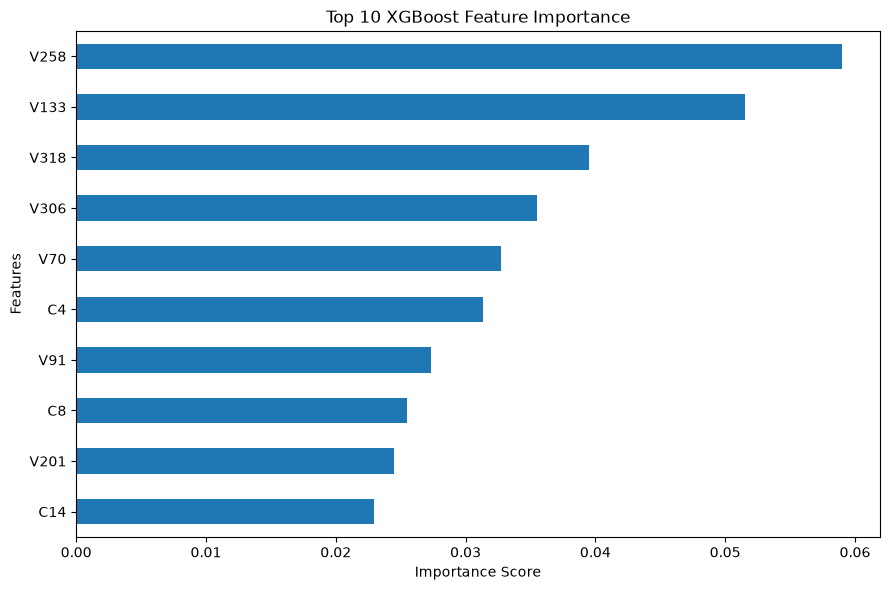

In [25]:
#Feature Ploting
top_features = importance.head(10)

plt.figure(figsize=(9, 6))

top_features.sort_values().plot(
    kind="barh"
)
plt.title(
    "Top 10 XGBoost Feature Importance"
)
plt.xlabel(
    "Importance Score"
)
plt.ylabel(
    "Features"
)
plt.tight_layout()
plt.savefig(
    "top_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
#Saving Final Predictions
prediction_df = pd.DataFrame({
    "Actual_Class": y_test.values,
    "Predicted_Class": y_pred,
    "Fraud_Probability": y_probability
})
prediction_df.to_csv(
    "final_fraud_predictions.csv",
    index=False
)
print("Final predictions saved successfully!")
print("File: final_fraud_predictions.csv")
display(prediction_df.head())

Final predictions saved successfully!
File: final_fraud_predictions.csv


,Actual_Class,Predicted_Class,Fraud_Probability
0,0,0,0.030400
1,0,0,0.118886
2,0,0,0.045525
3,0,0,0.015312
4,0,0,0.048122
